# Week 9 Exercise: Visualization Principles

## Redesigning Charts with Tufte's Principles

**Time:** 30 minutes

**Objective:** Apply Edward Tufte's visualization principles to redesign three "bad" visualizations, focusing on data-ink ratio, chart type selection, and purposeful use of color.

### Key Principles to Apply:

1. **Data-Ink Ratio:** Maximize the proportion of ink devoted to data
2. **Chart Type Selection:** Choose the right chart for the data and message
3. **Purposeful Color:** Use color to convey meaning, not decoration
4. **Clarity Over Decoration:** Remove chartjunk and unnecessary elements

---

## Setup: Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Budget Execution dataset
# File location: data/EJECUCION_PRESUPUESTAL.csv
df = pd.read_csv('data/EJECUCION_PRESUPUESTAL.csv')

# Quick overview
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (3645, 21)

Column names:
['Fuente de Financiación', 'Situación de Fondos', 'Recursos´Presupuestales', 'Codigo Sector', 'Nombre Sector', 'Codigo Entidad', 'Nombre Entidad', 'Código Nivel Uno Rubro', 'Nombre Nivel Uno Rubro', 'Código Nivel Dos Rubro', 'Nombre Niel Dos Rubro', 'Código Nivel Tres Rubro', 'Nombre Nivel Tres Rubro', 'Código Cuarto Nivel Rubro', 'Nombre Cuarto Nivel Rubro', 'Código Quinto Nivel Rubro', 'Nombre Quinto Nivel Rubro', 'Apropiación Vigente', 'Compromisos', 'Obligaciones', 'Pagos']


In [3]:
# Preview the data
df.head()

,Fuente de Financiación,Situación de Fondos,Recursos´Presupuestales,Codigo Sector,Nombre Sector,Codigo Entidad,Nombre Entidad,Código Nivel Uno Rubro,Nombre Nivel Uno Rubro,Código Nivel Dos Rubro,...,Código Nivel Tres Rubro,Nombre Nivel Tres Rubro,Código Cuarto Nivel Rubro,Nombre Cuarto Nivel Rubro,Código Quinto Nivel Rubro,Nombre Quinto Nivel Rubro,Apropiación Vigente,Compromisos,Obligaciones,Pagos
0,Nación,CSF,FONDO ESPECIAL FAZNI,7,MINAS Y ENERGIA,21-01-01,MINISTERIO DE MINAS Y ENERGIA - GESTION GENERAL,C,INVERSION,2102,...,1900,INTERSUBSECTORIAL MINAS Y ENERGÍA,15,AMPLIACION DE LA COBERTURA DEL SERVICIO DE ENE...,40301C,"4. TRANSFORMACIÓN PRODUCTIVA, INTERNACIONALIZA...",230000000000,218423934193,0,0
1,Nación,CSF,FONDO ESPECIAL FAZNI,7,MINAS Y ENERGIA,21-01-01,MINISTERIO DE MINAS Y ENERGIA - GESTION GENERAL,C,INVERSION,2102,...,1900,INTERSUBSECTORIAL MINAS Y ENERGÍA,20,DESARROLLO DE ESTRATEGIAS DE IMPLEMENTACIÓN EN...,40301A,"4. TRANSFORMACIÓN PRODUCTIVA, INTERNACIONALIZA...",300000000000,243608082077,0,0
2,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,A,FUNCIONAMIENTO,3,...,03,A ENTIDADES DEL GOBIERNO,01,A ÓRGANOS DEL PGN,032,FONDO NACIONAL DE SEGURIDAD Y CONVIVENCIA CIUD...,627264000000,528982310030,0,0
3,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,C,INVERSION,3702,...,1000,INTERSUBSECTORIAL GOBIERNO,13,FORTALECIMIENTO A LAS ENTIDADES TERRITORIALES ...,20105A,2. SEGURIDAD HUMANA Y JUSTICIA SOCIAL / A. NUE...,81291000000,17203016261,0,0
4,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,C,INVERSION,3702,...,1000,INTERSUBSECTORIAL GOBIERNO,8,FORTALECIMIENTO DE LOS SISTEMAS INTEGRADOS DE ...,20105A,2. SEGURIDAD HUMANA Y JUSTICIA SOCIAL / A. NUE...,60000000000,49717952500,0,0


In [4]:
# Prepare sample data for exercises
# Create aggregated data by category

# Sample data if dataset columns vary
np.random.seed(42)

# Budget categories sample data
categories = ['Education', 'Health', 'Infrastructure', 'Security', 'Social Programs']
budget_data = pd.DataFrame({
    'Category': categories,
    'Budget_Approved': [450, 380, 290, 220, 160],
    'Budget_Executed': [420, 350, 310, 195, 145]
})

# Monthly execution data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = pd.DataFrame({
    'Month': months,
    'Execution_Rate': [8.2, 16.5, 25.1, 33.8, 42.0, 50.5, 58.9, 67.2, 75.8, 84.1, 92.3, 100.0],
    'Target': [8.3, 16.7, 25.0, 33.3, 41.7, 50.0, 58.3, 66.7, 75.0, 83.3, 91.7, 100.0]
})

# Department data
dept_data = pd.DataFrame({
    'Department': ['Finance', 'HR', 'IT', 'Operations', 'Marketing', 'Legal'],
    'Execution_Pct': [95.2, 88.7, 92.1, 78.4, 85.6, 91.3]
})

print("Sample data prepared!")

Sample data prepared!


---

## Task 1: Redesign a 3D Pie Chart (10 minutes)

**Problem:** The following visualization uses a 3D pie chart to show budget allocation by category. 3D pie charts distort proportions and violate Tufte's principles.

**Your Mission:**
1. Identify what is wrong with the original
2. Choose a better chart type
3. Apply the data-ink ratio principle

---

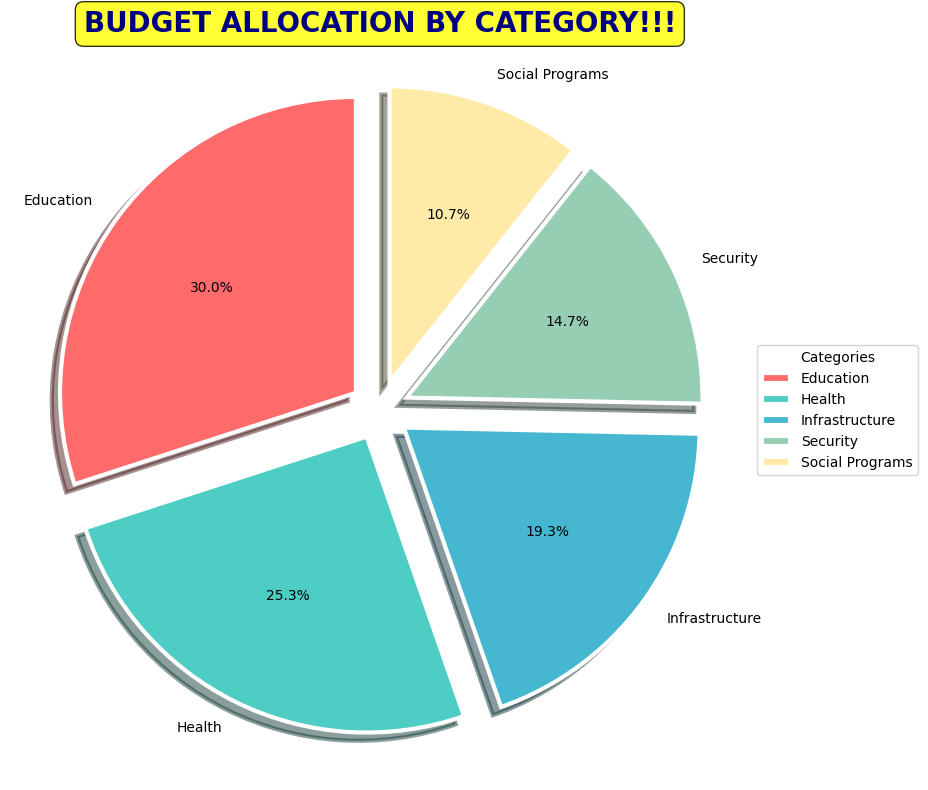


 What is WRONG with this visualization?


In [5]:
# BAD VISUALIZATION: 3D Pie Chart with Excessive Decoration

fig, ax = plt.subplots(figsize=(10, 8))

# Explode all slices (bad practice)
explode = (0.1, 0.1, 0.1, 0.1, 0.1)

# Garish colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Create pie chart with shadows and excessive styling
wedges, texts, autotexts = ax.pie(
    budget_data['Budget_Approved'],
    labels=budget_data['Category'],
    autopct='%1.1f%%',
    explode=explode,
    colors=colors,
    shadow=True,
    startangle=90,
    wedgeprops={'linewidth': 3, 'edgecolor': 'white'}
)

# Add unnecessary border
circle = plt.Circle((0, 0), 0.6, fc='white', linewidth=3, edgecolor='gray')

# Excessive title styling
ax.set_title('BUDGET ALLOCATION BY CATEGORY!!!', 
             fontsize=20, fontweight='bold', color='navy',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Add unnecessary legend
ax.legend(wedges, budget_data['Category'],
          title="Categories",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

print("\n What is WRONG with this visualization?")

### Identify the Problems

List at least 4 problems with the visualization above:

1. The use of a 3D pie chart distors the datra and makes it  difficult to accurately compare proportions.
2. All sides are explored, which adds unnecessary visual cluttler and does not highlight any specific category.
3. The use of bright and inconsistent colors distracting and does not improve readability.
4. Shadows and 3D effects add non-essential elements that do not convey additional information.
5. Pie charts in general make it harder to campare values compared to bar charts.
6. The char contains excessive "chartjunk", reducing the data-ink ratio.

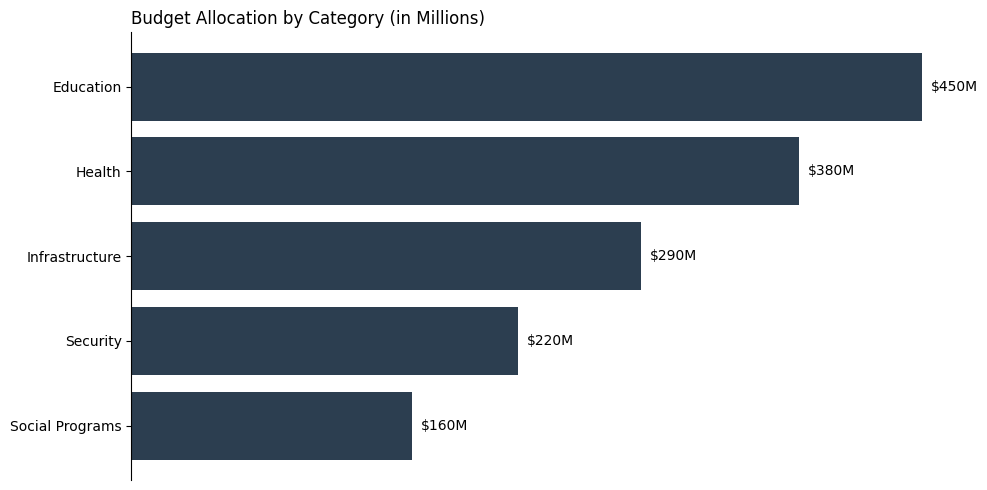

In [8]:
# YOUR REDESIGN: Create a Better Visualization
# 
# Hints:
# - Consider a horizontal bar chart for easy comparison
# - Use a single, muted color or grayscale
# - Remove all unnecessary elements
# - Show exact values, not just percentages

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE
# Create a horizontal bar chart

# Sort data for easier reading
sorted_data = budget_data.sort_values('Budget_Approved', ascending=True)

# Create horizontal bars
bars = ax.barh(
    sorted_data['Category'],
    sorted_data['Budget_Approved'],
    color= '#2C3E50',  # Choose a single, professional color (e.g., 'steelblue', '#2C3E50')
    edgecolor='none'
)

# Add value labels at the end of each bar
for bar, value in zip(bars, sorted_data['Budget_Approved']):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f'${value}M',
        va='center',
        fontsize=10
    )

# Remove unnecessary elements (Tufte's data-ink ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])  # Remove x-axis ticks since we have labels

# Clean title
ax.set_title('Budget Allocation by Category (in Millions)', fontsize=12, loc='left')

plt.tight_layout()
plt.show()

---

## Task 2: Fix a Cluttered Line Chart (10 minutes)

**Problem:** The following line chart shows monthly budget execution but has excessive gridlines, unnecessary markers, and distracting colors.

**Your Mission:**
1. Simplify the gridlines
2. Use color purposefully (highlight deviation from target)
3. Remove chartjunk

---

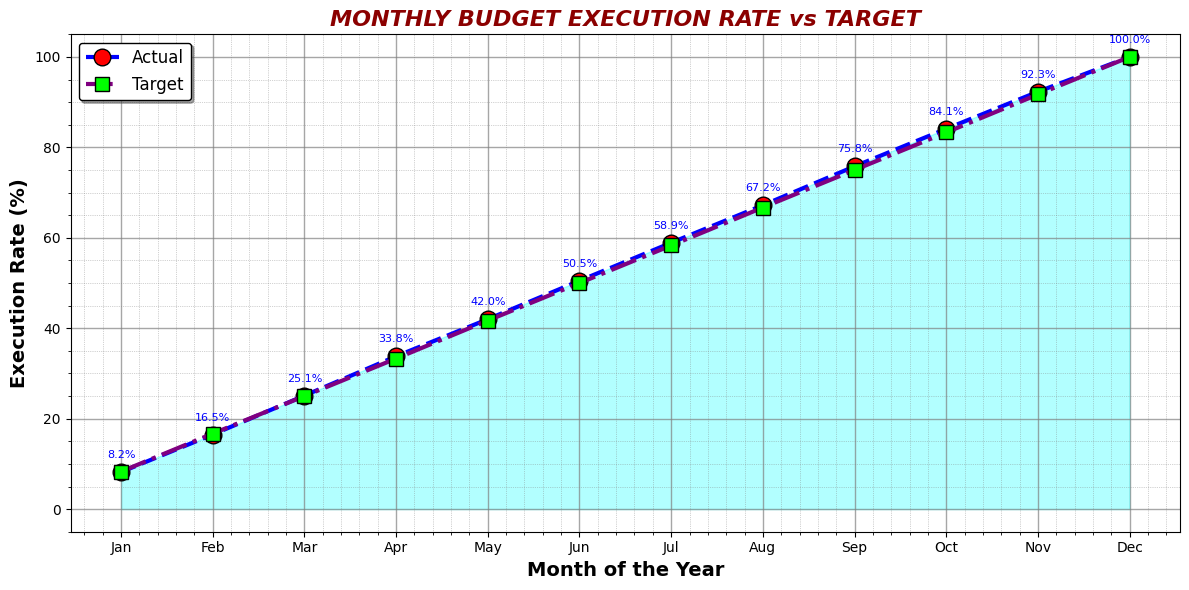


 What is WRONG with this visualization?


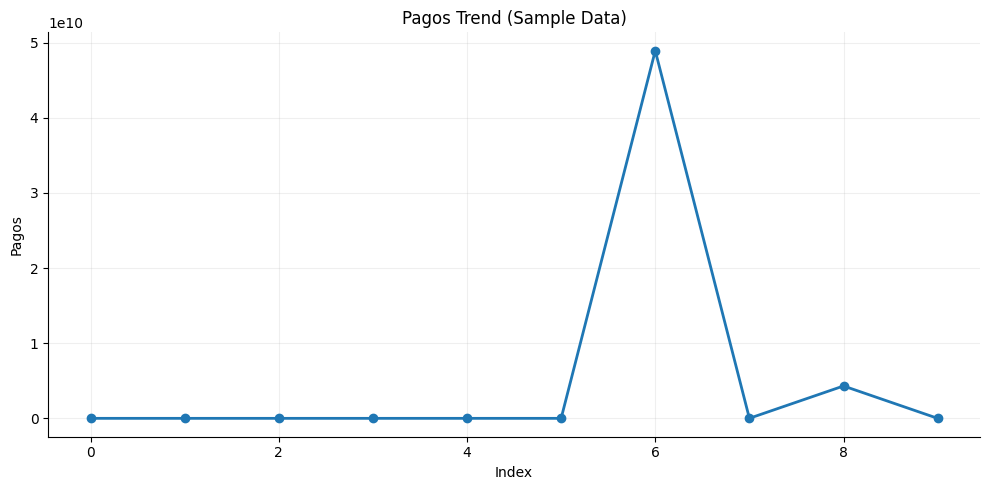

In [14]:
# BAD VISUALIZATION: Cluttered Line Chart

fig, ax = plt.subplots(figsize=(12, 6))

# Too many gridlines
ax.grid(True, which='both', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')

# Excessive markers and line styling
ax.plot(monthly_data['Month'], monthly_data['Execution_Rate'],
        marker='o', markersize=12, markerfacecolor='red', markeredgecolor='black',
        linestyle='--', linewidth=3, color='blue', label='Actual')

ax.plot(monthly_data['Month'], monthly_data['Target'],
        marker='s', markersize=10, markerfacecolor='lime', markeredgecolor='black',
        linestyle='-.', linewidth=3, color='purple', label='Target')

# Unnecessary fill
ax.fill_between(monthly_data['Month'], monthly_data['Execution_Rate'],
                alpha=0.3, color='cyan')

# Over-styled title and labels
ax.set_title('MONTHLY BUDGET EXECUTION RATE vs TARGET', fontsize=16, fontweight='bold',
             color='darkred', style='italic')
ax.set_xlabel('Month of the Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Execution Rate (%)', fontsize=14, fontweight='bold')

# Legend with unnecessary styling
ax.legend(loc='upper left', fontsize=12, shadow=True, fancybox=True,
          framealpha=1, edgecolor='black')

# Add unnecessary text annotations everywhere
for i, (rate, target) in enumerate(zip(monthly_data['Execution_Rate'], monthly_data['Target'])):
    ax.annotate(f'{rate}%', (i, rate), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8, color='blue')

plt.tight_layout()
plt.show()

print("\n What is WRONG with this visualization?")


# My DESIIIIIIIIING
# Clean column names (muy importante)
df.columns = df.columns.str.strip()

# Tomar una muestra para no saturar el gráfico
sample_data = df.head(10)

# Crear gráfico limpio
plt.figure(figsize=(10,5))

plt.plot(
    sample_data.index,
    sample_data['Pagos'],
    marker='o',
    linewidth=2
)

# Diseño limpio
plt.title('Pagos Trend (Sample Data)')
plt.xlabel('Index')
plt.ylabel('Pagos')

plt.grid(alpha=0.2)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Identify the Problems

List at least 4 problems with the visualization above:

1. The chart includes too many visual elemnts such as excessive gridlines, markers, and background shading. which create visual clutter.
2. The use of bright colors and filled areas diustracs from the acutal data trend.
3. Data labels are overcrowded and unnecessary, making the chart harder to read.
4. The combination of line, markers, and area fill is redundant and does not improve understanding.
5. The gridlines are too prominet and compete with the data for attention.
6. The chart violates the data-ink ratio principle by including too much non-essential information.

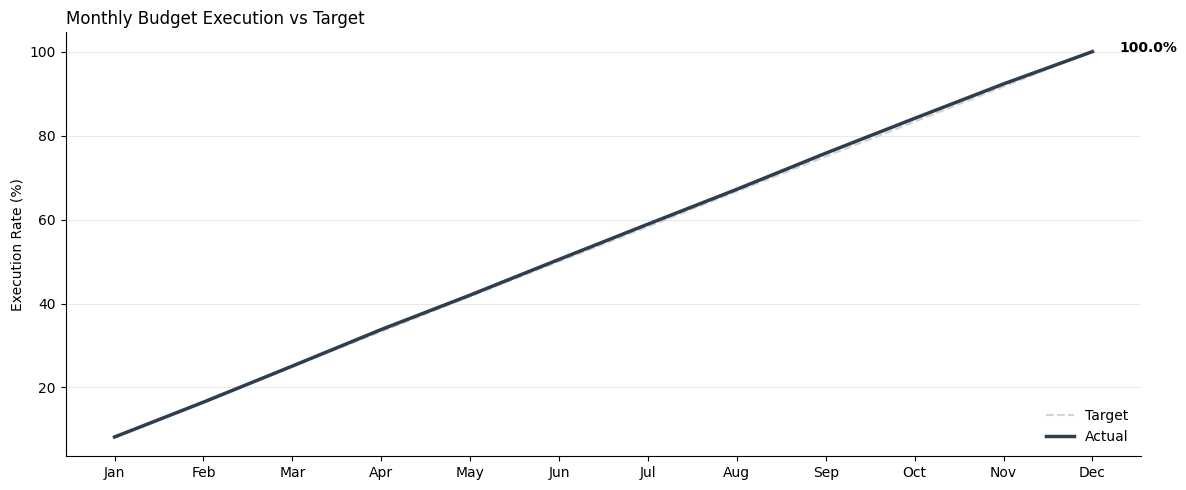

In [17]:
# YOUR REDESIGN: Create a Cleaner Line Chart
#
# Hints:
# - Use minimal gridlines (horizontal only, light gray)
# - Use color purposefully: gray for target, a single color for actual
# - Highlight only the key insight (are we ahead or behind?)
# - Remove markers or make them very subtle

fig, ax = plt.subplots(figsize=(12, 5))

# YOUR CODE HERE

# Plot target line (subtle, in the background)
ax.plot(monthly_data['Month'], monthly_data['Target'],
        linestyle='--', linewidth=1.5, color= '#D3D3D3',  # Use a light gray
        label='Target')

# Plot actual execution (prominent)
ax.plot(monthly_data['Month'], monthly_data['Execution_Rate'],
        linestyle='-', linewidth=2.5, color='#2C3E50',  # Use a professional blue
        label='Actual')

# Minimal gridlines (horizontal only)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Clean labels
ax.set_xlabel('')  # Month labels are self-explanatory
ax.set_ylabel('Execution Rate (%)', fontsize=10)
ax.set_title('Monthly Budget Execution vs Target', fontsize=12, loc='left', fontweight='normal')

# Simple legend
ax.legend(loc='lower right', frameon=False)

# Annotate only the final value (key insight)
final_actual = monthly_data['Execution_Rate'].iloc[-1]
ax.annotate(f'{final_actual}%', 
            xy=(11, final_actual),
            xytext=(11.3, final_actual),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Task 3: Redesign a Rainbow Bar Chart (10 minutes)

**Problem:** The following bar chart uses a different color for each bar (rainbow effect) which provides no additional information and is visually distracting.

**Your Mission:**
1. Use color purposefully (highlight one key insight)
2. Sort the data meaningfully
3. Apply consistent, professional styling

---

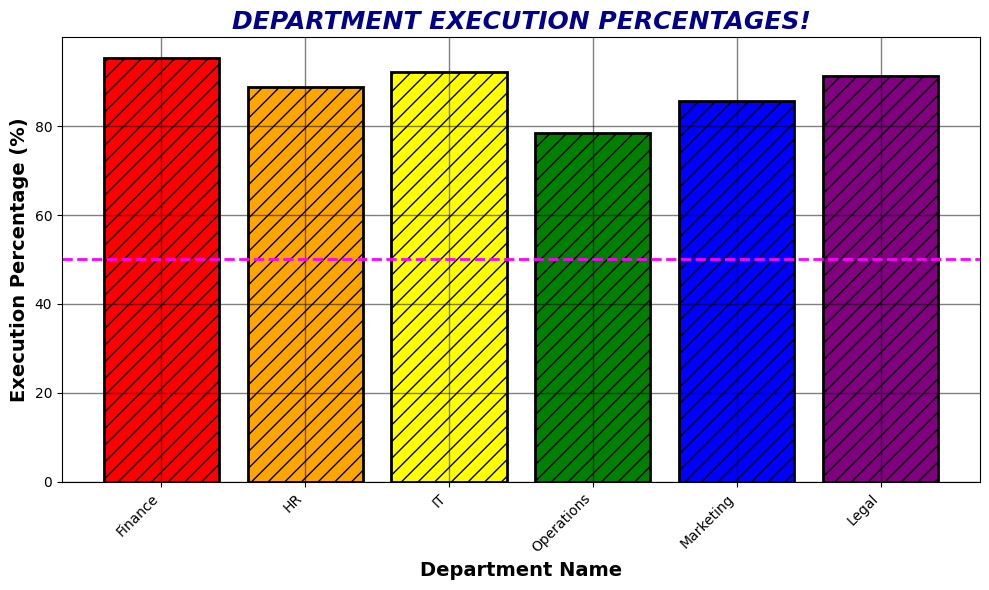


 What is WRONG with this visualization?


In [18]:
# BAD VISUALIZATION: Rainbow Bar Chart

fig, ax = plt.subplots(figsize=(10, 6))

# Rainbow colors (provides no information)
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

# Bars with heavy black edges
bars = ax.bar(dept_data['Department'], dept_data['Execution_Pct'],
              color=colors, edgecolor='black', linewidth=2)

# Add a distracting pattern
for bar, color in zip(bars, colors):
    bar.set_hatch('//')

# Excessive gridlines
ax.yaxis.grid(True, linestyle='-', linewidth=1, color='black', alpha=0.5)
ax.xaxis.grid(True, linestyle='-', linewidth=1, color='black', alpha=0.5)

# Unnecessary horizontal line at arbitrary position
ax.axhline(y=50, color='magenta', linestyle='--', linewidth=2, label='50% Line')

# Over-styled everything
ax.set_title('DEPARTMENT EXECUTION PERCENTAGES!', fontsize=18, fontweight='bold',
             color='darkblue', style='italic')
ax.set_xlabel('Department Name', fontsize=14, fontweight='bold')
ax.set_ylabel('Execution Percentage (%)', fontsize=14, fontweight='bold')

# Rotate labels unnecessarily
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n What is WRONG with this visualization?")

### Identify the Problems

List at least 4 problems with the visualization above:

1. The chart uses overly bright and satured colors that distrac from the data.
2. The hatch patterns on all bars create unnecessary visual clutter.
3. The gridlines are too strong and compete with the data for attention.
4. The rotated x-axis labels are unnecessary and reduce readability.
5. The decorative title style (all caps and color) is distracting and professional.
6. The horizontal reference line is not clearly explained and adds confusion.

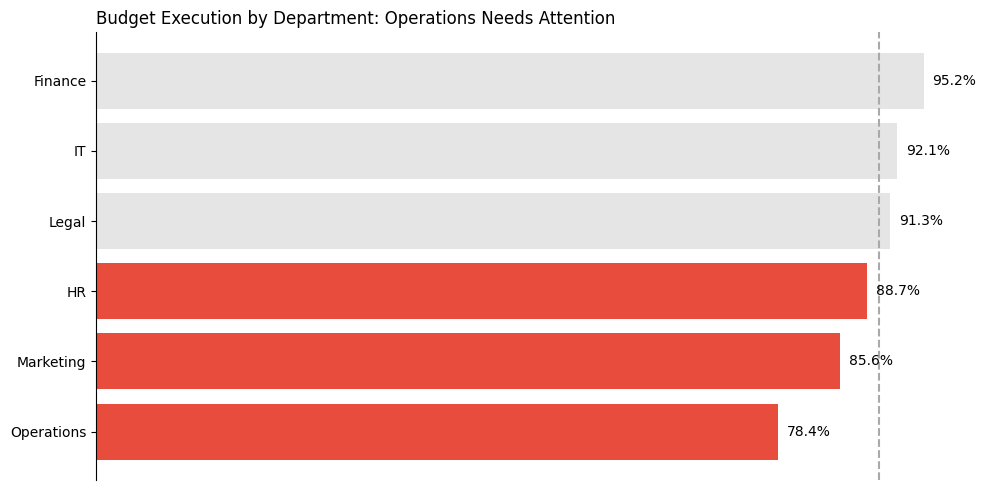

In [20]:
# YOUR REDESIGN: Create a Purposeful Bar Chart
#
# Hints:
# - Use ONE color for all bars, OR use color to highlight a specific insight
#   (e.g., highlight the department below target in red)
# - Sort bars by value for easier comparison
# - Add a meaningful reference line (e.g., 90% target)
# - Remove unnecessary gridlines

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE

# Sort data by execution percentage
sorted_dept = dept_data.sort_values('Execution_Pct', ascending=True)

# Define target threshold
target = 90

# Use color to highlight which departments are below target
colors = ['#E5E5E5' if val >= target else '#E74C3C' for val in sorted_dept['Execution_Pct']]
# Hint: Use a muted blue/gray for above target, a warning color (orange/red) for below

# Create horizontal bar chart
bars = ax.barh(
    sorted_dept['Department'],
    sorted_dept['Execution_Pct'],
    color=colors,
    edgecolor='none'
)

# Add target reference line
ax.axvline(x=target, color='darkgray', linestyle='--', linewidth=1.5, label=f'{target}% Target')

# Add value labels
for bar, value in zip(bars, sorted_dept['Execution_Pct']):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{value:.1f}%',
        va='center',
        fontsize=10
    )

# Remove unnecessary elements
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])

# Clean title that tells the story
ax.set_title('Budget Execution by Department: Operations Needs Attention', fontsize=12, loc='left')

plt.tight_layout()
plt.show()

---

## Summary: Tufte's Visualization Principles

### Data-Ink Ratio

```
Data-Ink Ratio = (Ink used to display data) / (Total ink used in the graphic)
```

**Goal:** Maximize this ratio by removing non-data ink.

### What to Remove (Chartjunk):

| Remove | Why |
|--------|-----|
| 3D effects | Distort proportions |
| Unnecessary gridlines | Visual clutter |
| Rainbow colors | Provide no information |
| Heavy borders | Distract from data |
| Shadows | Pure decoration |
| Hatching patterns | Hard to read |
| Excessive markers | Visual noise |

### When to Use Color:

| Use Color For | Example |
|---------------|----------|
| Highlighting key data | Red for "below target" |
| Grouping categories | Same color = same group |
| Sequential values | Light to dark gradient |
| Diverging from center | Red-White-Blue for +/- |

### Chart Type Selection:

| Data Type | Best Chart |
|-----------|------------|
| Parts of whole | Stacked bar (not pie) |
| Comparison | Horizontal bar |
| Trend over time | Line chart |
| Distribution | Histogram, box plot |
| Relationship | Scatter plot |

---

## Reflection

Answer these questions:

1. **Which redesign improved the most?** Why?

   _Your answer:_
   The first redesign (pie chart to bar chart) improved the most because it transformed a misleading and hard-to-read visualization into a clear and accurate one. Bar charts make it easier to compare values, while the original 3D pie chart distorted proportions and added unnecessary visual clutter.

2. **When is it OK to use multiple colors?**

   _Your answer:_
   It is appropriate to use multiple colors when they serve a clear purpose, such as highlighting differences, categories, or emphasizing important data points. Colors should not be used purely for decoration but to guide the viewer’s attention and improve understanding.

3. **What is the main message each visualization should convey?**

   - Task 1: Show clear comparison between budget categories
   - Task 2: Show the trend over time clearly and without distractions
   - Task 3: Highlight which departments meet or fall below the target

---

*End of Exercise*